# ACTIVIDAD M22

### El objetivo de esta actividad es que efectúes un análisis de clasificación mediante Máquinas de soporte vectorial que permita desarrollar un modelo predictivo basado en distintas métricas aplicadas a una base de datos grande.

- Considere la base de datos “recursos_humanos.csv” sobre empleados que abandonan una empresa.
- El objetivo es analizar porqué los empleados deciden irse con la competencia y éste podría ser un desafío serio para un departamento de recursos humanos, el cual se podría abordar mediante modelos predictivos de Machine Learning. Las variables manejadas son:
    * satisfaction_level: Nivel de satisfacción. 
    * last_evaluation: Puntaje obtenido en la ultima evaluación. 

    * average_montly_hours: Promedio de horas trabajadas al mes. 

    * time_spend_company: Tiempo del usuario en la compañía. 

    * work_accident: Si el empleado ha tenido algún accidente laboral (1 = Sí, 0 = No). 

    * promotion_last_5years: Si el empleado ha sido promovido en los últimos 5 años. 

    * sales: Departamento donde trabaja. 

    * salary: Categoría del salario. 

    * left: Variable a predecir y si el empleado dejó o no la empresa (1 = Sí, 0 = No).
- ### Cargue la base de datos en Python y asegúrese de re-codificar las variables categóricas de manera pertinente antes de iniciar su análisis

In [1]:
import pandas as pd
import pylab as pl
import numpy as np
import seaborn as sns
import scipy.optimize as opt

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn import svm
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv('leccion 7/recursos_humanos.csv')
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [2]:
data_dummy = pd.get_dummies(data, columns=['sales','salary'], dtype=int)

In [3]:
data_dummy

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_IT,sales_RandD,...,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14995,0.37,0.48,2,160,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14996,0.37,0.53,2,143,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14997,0.11,0.96,6,280,4,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0


* ### Use el método de Máquinas de soporte vectorial para generar un modelo predictivo. Para dicho fin, pruebe los 4 diferentes tipos de Kernel discutidos en esta lección. En cada caso elabore un mapa de calor para las matrices de confusión así como un reporte de clasificación detallado. Interprete verbalmente sus indicadores. 

In [4]:
y = data_dummy.left.values
x_data = data_dummy.drop(['left'], axis = 1)
# Normalizacion
x = (x_data - x_data.min()) / (x_data.max() - x_data.min())

In [5]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=4)
print('Grupo de entrenamiento', x_train.shape, y_train.shape)
print('Grupo de prueba', x_test.shape, y_test.shape)

Grupo de entrenamiento (11999, 20) (11999,)
Grupo de prueba (3000, 20) (3000,)


***
 ## 1.Kernel Radial Basis function (RBF)
***

In [6]:
clf= svm.SVC(kernel = 'rbf')
clf.fit(x_train, y_train)
yhat= clf.predict(x_test)
y_pred = clf.predict(x)
cm = confusion_matrix(y_test, yhat)
cm

array([[2215,   72],
       [  85,  628]])

<function matplotlib.pyplot.show(close=None, block=None)>

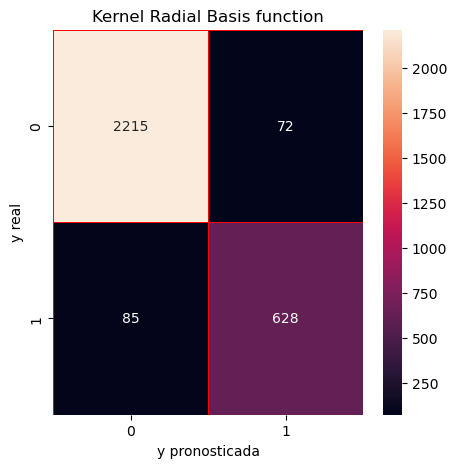

In [7]:
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot = True, linewidths = 0.5, linecolor = 'red', fmt = '.0f', ax = ax)
plt.title('Kernel Radial Basis function')
plt.xlabel('y pronosticada')
plt.ylabel('y real')
plt.show

### Estadisticas de desempleño Radial Basis function (RBF)


In [8]:
print(classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      2287
           1       0.90      0.88      0.89       713

    accuracy                           0.95      3000
   macro avg       0.93      0.92      0.93      3000
weighted avg       0.95      0.95      0.95      3000



***
 ## 2. Kernel Lineal
***

<function matplotlib.pyplot.show(close=None, block=None)>

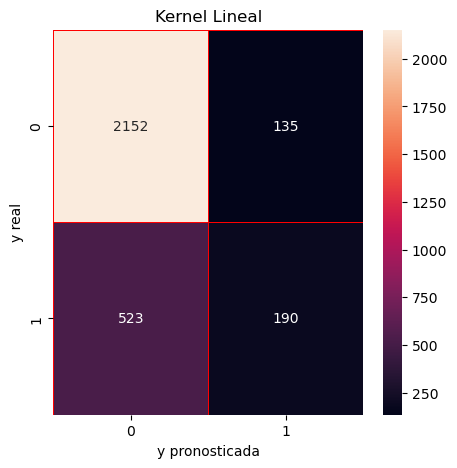

In [9]:
clf = svm.SVC(kernel = 'linear')
clf.fit (x_train, y_train)

yhat = clf.predict (x_test)

#Confusion matrix
from sklearn.metrics import confusion_matrix
y_pred = clf.predict (x)
cm= confusion_matrix (y_test,yhat)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot = True, linewidths = 0.5, linecolor = 'red', fmt = '.0f', ax = ax)
plt.title('Kernel Lineal')
plt.xlabel('y pronosticada')
plt.ylabel('y real')
plt.show

### Estadisticas de desempleño Kernel Lineal

In [10]:
print (classification_report (y_test,yhat))

              precision    recall  f1-score   support

           0       0.80      0.94      0.87      2287
           1       0.58      0.27      0.37       713

    accuracy                           0.78      3000
   macro avg       0.69      0.60      0.62      3000
weighted avg       0.75      0.78      0.75      3000



***
 ## 3. Kernel Polimonial
***

<function matplotlib.pyplot.show(close=None, block=None)>

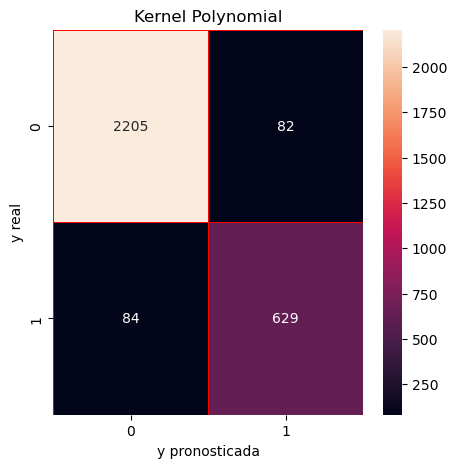

In [11]:
clf = svm.SVC(kernel = 'poly')
clf.fit (x_train, y_train)

yhat = clf.predict (x_test)

#Confusion matrix
from sklearn.metrics import confusion_matrix
y_pred = clf.predict (x)
cm= confusion_matrix (y_test,yhat)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot = True, linewidths = 0.5, linecolor = 'red', fmt = '.0f', ax = ax)
plt.title('Kernel Polynomial')
plt.xlabel('y pronosticada')
plt.ylabel('y real')
plt.show

### Estadisticas de desempleño Kernel Polimonial

In [12]:
print (classification_report (y_test,yhat))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2287
           1       0.88      0.88      0.88       713

    accuracy                           0.94      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.94      0.94      0.94      3000



***
 ## 4. Kernel Sigmoide
***

<function matplotlib.pyplot.show(close=None, block=None)>

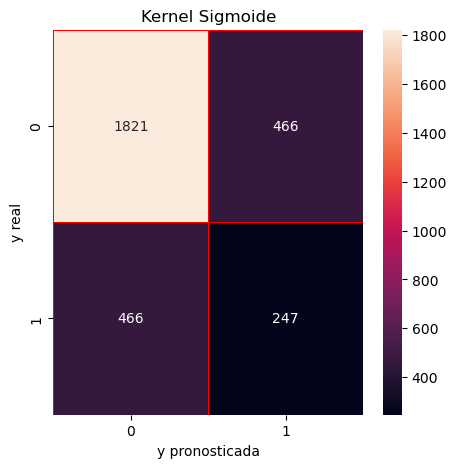

In [13]:
clf = svm.SVC(kernel = 'sigmoid')
clf.fit (x_train, y_train)

yhat = clf.predict (x_test)
#Confusion matrix
from sklearn.metrics import confusion_matrix
y_pred = clf.predict (x)
cm= confusion_matrix (y_test,yhat)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot = True, linewidths = 0.5, linecolor = 'red', fmt = '.0f', ax = ax)
plt.title('Kernel Sigmoide')
plt.xlabel('y pronosticada')
plt.ylabel('y real')
plt.show

### Estadisticas de desempleño Kernel Sigmoide

In [14]:
print (classification_report (y_test,yhat))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      2287
           1       0.35      0.35      0.35       713

    accuracy                           0.69      3000
   macro avg       0.57      0.57      0.57      3000
weighted avg       0.69      0.69      0.69      3000



*** 
* ### ¿Cuál resultó ser el modelo predictivo más adecuado? Explique su razonamiento.
El modelo kernel RBF obtuvo mayor porcentaje de exactitud, logrando pronosticar tanto a las personas que dejan la empresa como a las que se quedan en un 95%  y mostro un desempeño mayo mostrando un porcentaje mayor o muy cercano a 90% en todos los indicadores. Además, la diferencia entre el macro average (0.93) y el weighted average (0.95) es mínima, lo que sugiere que el modelo mantiene un rendimiento consistente entre las clases y no presenta un sesgo importante hacia la clase mayoritaria.


***
* ### ¿Qué resultado pronosticaría para un empleado con los siguientes indicadores?
| satisfaction_level | last_evaluation | number_project | average_mountly_hours | time_spend_company | work_accidents | promotion_last_5years | sales | salary |
|--------------------|-----------------|----------------|-----------------------|--------------------|----------------|-----------------------|-------|--------|
| 0.5                | 0.75            | 4              | 200                   | 4                  | 0              | 0                     | sales | medium |

In [15]:
query = {
    'satisfaction_level' : [0.5],
    'last_evaluation' : [0.74],
    'number_project' : [4],
    'average_mountly_hours' : [200],
    'time_spend_company' : [4],
    'work_accidents' : [0],
    'promotion_last_5years' : [0],
    'sales' : ['sales'],
    'salary': ['medium'] 
}
dfQuery = pd.DataFrame(query)
dfQuery

,satisfaction_level,last_evaluation,number_project,average_mountly_hours,time_spend_company,work_accidents,promotion_last_5years,sales,salary
0,0.5,0.74,4,200,4,0,0,sales,medium


In [16]:
dfQueryNew = pd.get_dummies(dfQuery,columns=['sales','salary'], dtype=int)

dfQueryNew = dfQueryNew.reindex(columns=x_train.columns,fill_value=0)
dfQueryNew

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_IT,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.5,0.74,4,0,4,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1


In [17]:
clf = svm.SVC(kernel='rbf', probability=True)
clf.fit(x_train, y_train)
probabilidad = clf.predict_proba(dfQueryNew)

print(probabilidad)

[[0.83416069 0.16583931]]


De acuerdo con el modelo RBF, existe un 83.4% de probabilidad de que el empleado continúe en la empresa, mientras que únicamente hay un 16.6% de probabilidad de que decida renunciar.

***